# Project: Image Classification & Object Detection  
### Using CNN, ResNet, and YOLO

## 📌 PART 1: Image Processing Basics

Before feeding images into deep learning models, **raw images must be preprocessed**.  
Image preprocessing helps models:

- Train faster  
- Converge more efficiently  
- Generalize better to unseen data  

---

## 🔹 Key Image Processing Concepts

### 1️⃣ Resizing

Neural networks require **fixed-size inputs**.

- All images are resized to the same dimensions  
- Prevents shape mismatch during batch training  
- Examples:  
  - `32 × 32` for CIFAR-10  
  - `224 × 224` for ResNet  

✔️ Ensures consistency across the dataset  

---

### 2️⃣ Normalization

Pixel values in raw images range from **0–255**.

- Scale values to **0–1** (or use mean–std normalization)  
- Improves numerical stability  
- Helps gradients converge faster  

📌 **Formula:**
```python
normalized_pixel = pixel_value / 255.0
```
---

### 3️⃣ Data Augmentation

Data augmentation **artificially increases the dataset size** by applying random transformations to training images.  
This helps the model learn more diverse patterns from limited data.

**Common techniques:**
- Horizontal flip  
- Random rotation  
- Random crop  
- Color jitter  

🎯 **Benefits:**
- Reduces overfitting  
- Improves robustness to variations  
- Helps the model generalize better to unseen images  

---

### 4️⃣ Tensor Conversion

Deep learning frameworks work with **tensors**, not raw images.

- Converts image → PyTorch Tensor  
- Rearranges image shape:


```
(Height, Width, Channels) → (Channels, Height, Width)
```

✔️ Required for GPU acceleration and efficient model training  

---

## 📂 Dataset: CIFAR-10

CIFAR-10 is a **standard benchmark dataset** widely used for image classification tasks.

### 🔢 Dataset Details
- **Total Images:** 60,000  
- **Training Images:** 50,000  
- **Test Images:** 10,000  
- **Image Size:** 32 × 32 (RGB)  
- **Number of Classes:** 10  

---

### 🏷️ Classes
- Airplane  
- Automobile  
- Bird  
- Cat  
- Deer  
- Dog  
- Frog  
- Horse  
- Ship  
- Truck  

📌 Each image belongs to **exactly one class**


### **Import Libraries**

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

### **Define Image Transformations**

In [ ]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

### **Load CIFAR-10 Dataset**

In [ ]:
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset,
                           batch_size=64,
                           shuffle=True)

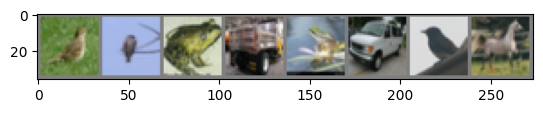

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:8]))

## 📌 PART 2: CNN – Intuition & Implementation

---

## 🧠 CNN Intuition

A **Convolutional Neural Network (CNN)** is designed to automatically learn **spatial features** from images such as edges, textures, shapes, and objects.

A typical CNN consists of the following layers:

---

### 1️⃣ Convolution Layer
- Applies learnable **filters (kernels)** over the input image  
- Extracts low-level and high-level features  
- Early layers detect edges and corners  
- Deeper layers detect shapes and objects  

📌 Output: **Feature maps**

---

### 2️⃣ ReLU (Rectified Linear Unit)
- Introduces **non-linearity** into the network  
- Helps the model learn complex patterns  

📌 Function:
`ReLU(x) = max(0, x)`

✔️ Prevents vanishing gradients and speeds up training  

---

### 3️⃣ Pooling Layer
- Reduces spatial dimensions (height & width)  
- Common type: **Max Pooling**  

🎯 Benefits:
- Reduces computation  
- Controls overfitting  
- Makes features more robust to small translations  

---

### 4️⃣ Fully Connected Layer
- Flattens feature maps into a 1D vector  
- Learns decision boundaries  
- Outputs class probabilities  

📌 Used for **final classification**

---

## ❓ Why CNN Works?

CNNs are powerful because they:

- Detect **edges → shapes → objects** hierarchically  
- Use **parameter sharing**, reducing model complexity  
- Provide **translation invariance** (objects recognized anywhere in the image)  



### **Define CNN Architecture**

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(-1, 64 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

### **Model Initialization**

In [ ]:
model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### **Training Loop**

In [ ]:
train_losses = []
train_accuracies = []

for epoch in range(10):

    correct = 0
    total = 0
    running_loss = 0.0

    model.train()   # Important for Dropout / BatchNorm

    for images, labels in train_loader:

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    # Store values
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    # Print values
    print(f"Epoch [{epoch+1}/10] "
          f"Loss: {epoch_loss:.4f} "
          f"Accuracy: {epoch_accuracy:.2f}%")

Epoch [1/10] Loss: 0.1556 Accuracy: 95.07%
Epoch [2/10] Loss: 0.1587 Accuracy: 94.92%
Epoch [3/10] Loss: 0.1576 Accuracy: 95.02%
Epoch [4/10] Loss: 0.1579 Accuracy: 94.99%
Epoch [5/10] Loss: 0.1585 Accuracy: 94.92%
Epoch [6/10] Loss: 0.1582 Accuracy: 95.02%
Epoch [7/10] Loss: 0.1579 Accuracy: 94.97%
Epoch [8/10] Loss: 0.1590 Accuracy: 94.90%
Epoch [9/10] Loss: 0.1587 Accuracy: 94.97%
Epoch [10/10] Loss: 0.1597 Accuracy: 94.93%


### **Model Predictions on Test Images**

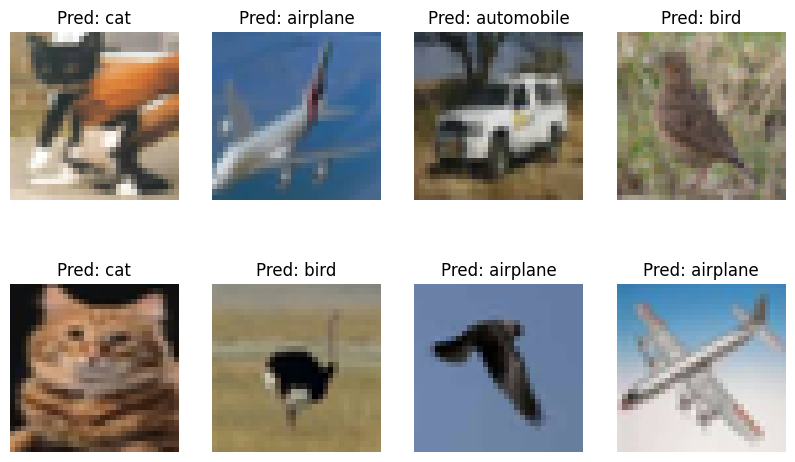

In [ ]:
classes = train_dataset.classes

images, labels = next(iter(train_loader))
outputs = model(images)

_, predicted = torch.max(outputs, 1)

fig = plt.figure(figsize=(10,6))

for i in range(8):
    ax = fig.add_subplot(2,4,i+1)
    img = images[i] / 2 + 0.5
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1,2,0)))
    ax.set_title(f"Pred: {classes[predicted[i]]}")
    ax.axis("off")

plt.show()

### **Visualize Feature Maps from First Conv Layer**

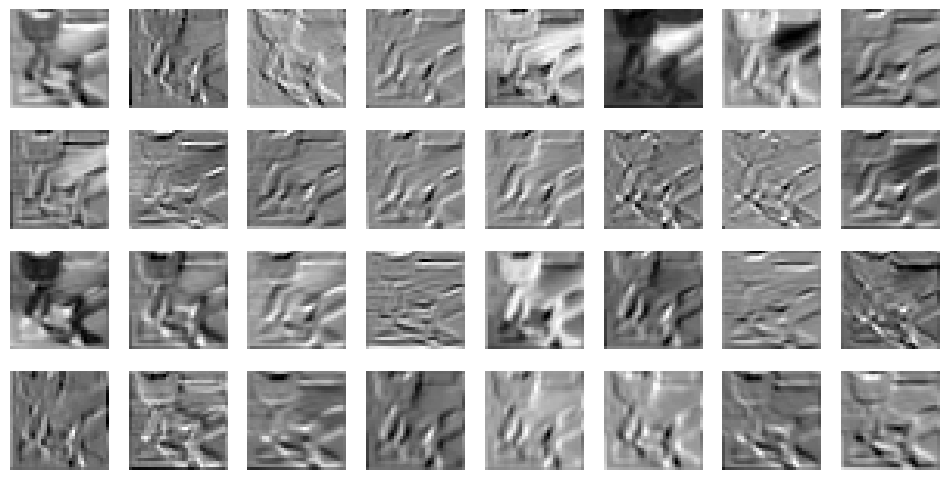

In [ ]:
def visualize_feature_maps(model, image):
    x = model.conv1(image.unsqueeze(0))
    x = x.detach()

    fig, axes = plt.subplots(4, 8, figsize=(12,6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(x[0][i], cmap='gray')
        ax.axis('off')
    plt.show()

visualize_feature_maps(model, images[0])

## 📌 PART 3: ResNet – Intuition & Transfer Learning

---

## 🧠 Problem: Vanishing Gradients

As neural networks become **deeper**, training becomes difficult due to:

- **Vanishing gradients**  
  - Gradients become very small during backpropagation  
  - Earlier layers learn very slowly or stop learning  

- **Degradation problem**  
  - Adding more layers leads to **higher training error**  
  - Deeper network performs worse than a shallower one  

📌 This happens even when overfitting is not the issue.

---

## 🚀 Solution: Residual Learning (ResNet)

**Residual Networks (ResNet)** solve this problem by introducing **skip connections**.

Instead of learning a full mapping, the network learns the **residual**.


Where:
- `x` = input to the block  
- `F(x)` = residual function (learned by convolution layers)  

✔️ The input is added directly to the output using a **skip connection**

---

## 💡 Why Residual Learning Works

- Allows gradients to flow directly through skip connections  
- Prevents vanishing gradients  
- Makes very deep networks trainable (50, 101, 152 layers)  

🎯 Key advantages:
- Easier optimization  
- Faster convergence  
- Better accuracy with depth  

---

## 🔄 ResNet + Transfer Learning

ResNet is often used with **transfer learning**:

- Use a **pretrained ResNet** (trained on ImageNet)  
- Reuse learned features (edges, textures, shapes)  
- Replace the final classification layer  
- Fine-tune on a new dataset (e.g., CIFAR-10)

🎯 Benefits:
- Requires less data  
- Faster training  
- Higher accuracy  




### **Load Pretrained ResNet18**

In [ ]:
from torchvision import models

resnet = models.resnet18(pretrained=True)

### **Modify Final Layer for CIFAR-10**

In [ ]:
resnet.fc = nn.Linear(resnet.fc.in_features, 10)

### **Train ResNet Model**

In [ ]:
optimizer = torch.optim.Adam(resnet.parameters(), lr=0.0001)

for epoch in range(5):

    resnet.train()   # Set model to training mode

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        outputs = resnet(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate loss
        running_loss += loss.item()

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Count total samples
        total += labels.size(0)

        # Count correct predictions
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/5] "
          f"Loss: {epoch_loss:.4f} "
          f"Accuracy: {epoch_accuracy:.2f}%")

## 📌 PART 4: Object Detection Overview (YOLO Concept)


### 🔍 Classification vs Detection

- **Image Classification** → *What object is present?*  
  - Example: Cat, Dog, Car  

- **Object Detection** → *What object + Where is it located?*  
  - Outputs **class label + bounding box (x, y, width, height)**  

📌 Detection is more challenging because it requires **localization + classification**.


**YOLO** stands for **You Only Look Once**.

Unlike traditional object detection methods, YOLO treats detection as a **single regression problem**.

---

### ❌ Traditional Approach (e.g., R-CNN family)

- Generate **region proposals**
- Run classification on each region
- Multiple stages → slow inference

---

### ✅ YOLO Approach

YOLO performs detection in **one single forward pass**.

It:
- Divides the image into a **grid**
- Each grid cell:
  - Predicts **bounding boxes**
  - Predicts **object confidence**
  - Predicts **class probabilities**

📌 All predictions are made **at once**, hence the name *You Only Look Once*.

---

### ⚡ Key Advantages of YOLO

- Extremely **fast** (real-time detection)
- End-to-end training
- Suitable for:
  - Video surveillance
  - Autonomous driving
  - Real-time applications

---

### 🧠 YOLO Intuition (Simple)



```
Input Image
↓
Single CNN Forward Pass
↓
Bounding Boxes + Class Labels
```

✔️ No separate region proposal step  
✔️ Entire image processed globally  







### **Install YOLO**

In [ ]:
pip install ultralytics

### **Load Pretrained YOLO Model**

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

### **Run Object Detection**

In [ ]:
results = model("object-detection.jpg")

results[0].show()

## **Real-World Applications**

- 🏥 Medical imaging

- 🚗 Autonomous vehicles

- 📦 Retail inventory

- 🔐 Surveillance

- 🛰️ Satellite imaging